## Aggregate & Merger Data with Pandas: Analyse the LEGO Dataset

On this day ill ecplore lego dataset, clean and manipulate data, use argg(), create line, scattter, and bar chart, work and manipulate datasets, understand primary and foreign keys and marge data frames 

Use HTML markodown to make your notebook look pretty

Exploring the LEGO brick colors

In [1]:
import pandas as pd

colors = pd.read_csv("colors.csv")

colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [2]:
colors.columns

Index(['id', 'name', 'rgb', 'is_trans'], dtype='object')

In [3]:
colors.shape

(135, 4)

find the number of unique colors

In [4]:
colors["name"].nunique()

135

In [5]:
colors["is_trans"].value_counts()

is_trans
f    107
t     28
Name: count, dtype: int64

find the oldest and largest lego sets

In [6]:
sets = pd.read_csv("sets.csv")

sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [7]:
sets.sort_values("year").head()

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12


In [8]:
sets["year"].min()

1949

In [9]:
sets.sort_values(
    "num_parts",
    ascending=False
).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


In [10]:
sets["num_parts"].max()

9987

In [11]:
#find the set
sets[
    sets["num_parts"] == sets["num_parts"].max()
]

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987


visualize number of sets published over time

In [13]:
sets_by_year = sets.groupby("year").size()

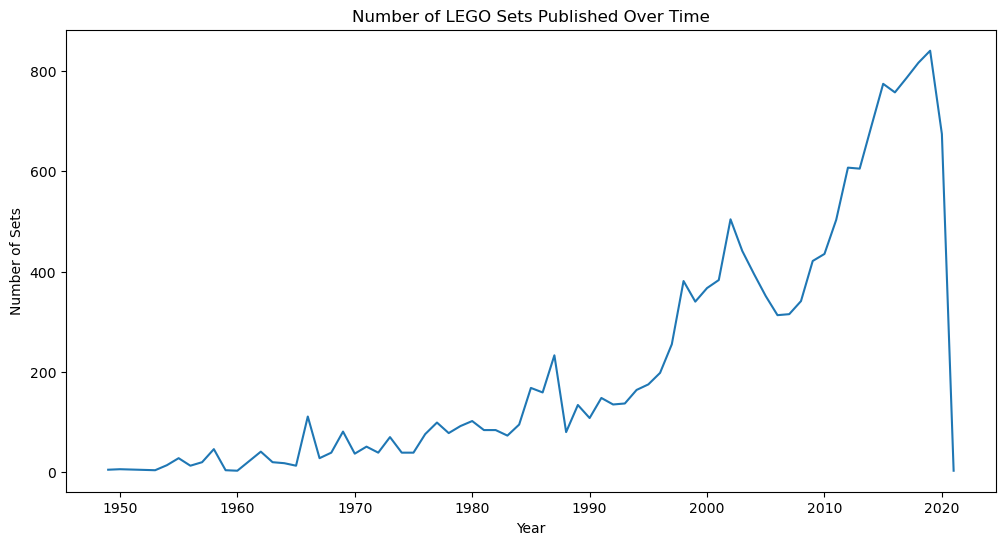

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    sets_by_year.index,
    sets_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Sets")
plt.title("Number of LEGO Sets Published Over Time")

plt.show()

how to use pandas argg function

it allows you to perform several calculations at once 


example;

In [15]:
sets["num_parts"].agg(
    ["mean", "median", "min", "max"]
)

mean       166.036346
median      45.000000
min          0.000000
max       9987.000000
Name: num_parts, dtype: float64

combine it with groupby

In [16]:
sets.groupby("year").agg({
    "num_parts": ["mean", "sum", "max"]
})

num_parts              
            mean     sum   max
year                          
1949   99.600000     498   178
1950    1.000000       6     1
1953   13.500000      54    48
1954   12.357143     173    54
1955   36.607143    1025   200
...          ...     ...   ...
2017  221.840967  174367  7541
2018  213.618873  174313  6020
2019  207.510714  174309  4784
2020  259.732938  175060  5547
2021    0.000000       0     0

[71 rows x 3 columns]

superimposing line charts with separate axes

In [18]:
avg_parts = sets.groupby("year")["num_parts"].mean()

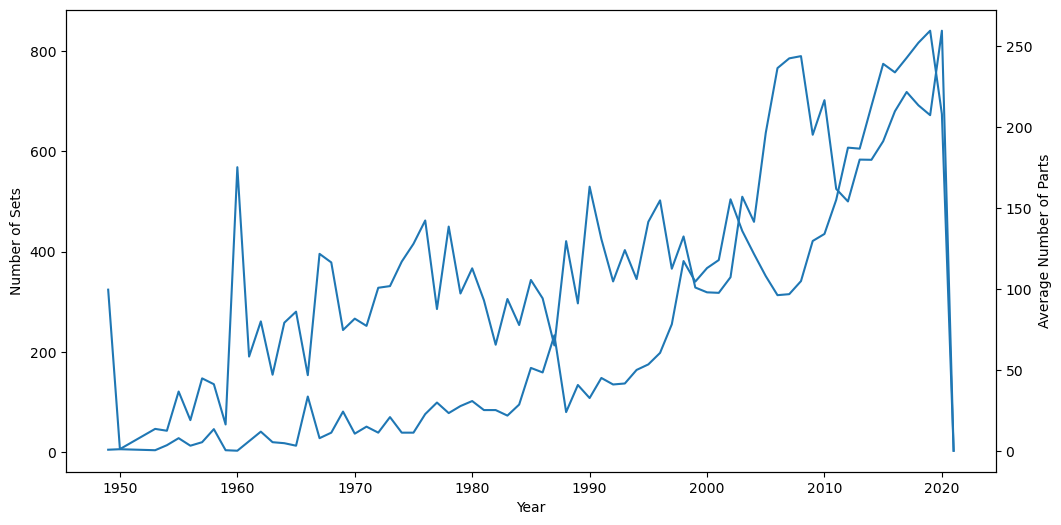

In [19]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    sets_by_year.index,
    sets_by_year.values
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Sets")

ax2 = ax1.twinx()

ax2.plot(
    avg_parts.index,
    avg_parts.values
)

ax2.set_ylabel("Average Number of Parts")

plt.show()

scatter plots

the scatter plot shows the number of individual observation as a point

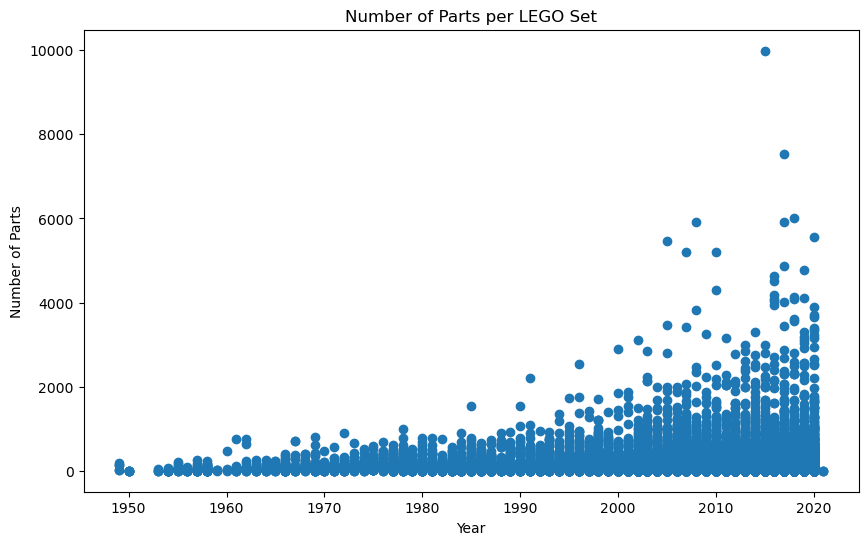

In [20]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sets["year"],
    sets["num_parts"]
)

plt.xlabel("Year")
plt.ylabel("Number of Parts")
plt.title("Number of Parts per LEGO Set")

plt.show()

relational database schemas

merge dataframes and create bar charts 

In [21]:
themes = pd.read_csv("themes.csv")

In [22]:
sets_with_themes = pd.merge(
    sets,
    themes,
    left_on="theme_id",
    right_on="id"
)

In [23]:
sets_with_themes.head()

,set_num,name_x,year,theme_id,num_parts,id,name_y,parent_id
0,001-1,Gears,1965,1,43,1,Technic,NaN
1,0011-2,Town Mini-Figures,1978,84,12,84,Supplemental,67.0
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,199,Lion Knights,186.0
3,0012-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0
4,0013-1,Space Mini-Figures,1979,143,12,143,Supplemental,126.0


chechk column

In [24]:
sets_with_themes.columns

Index(['set_num', 'name_x', 'year', 'theme_id', 'num_parts', 'id', 'name_y',
       'parent_id'],
      dtype='object')

count set by theme

In [25]:
sets_by_theme = (
    sets_with_themes
    .groupby("name_y")
    .size()
    .sort_values(ascending=False)
)

take top 10

In [26]:
sets_by_theme.head(10)

name_y
Star Wars       776
Gear            656
Basic Set       558
Supplemental    535
Technic         453
Friends         415
Ninjago         360
Town            360
Key Chain       329
Books           310
dtype: int64

make the bar chart

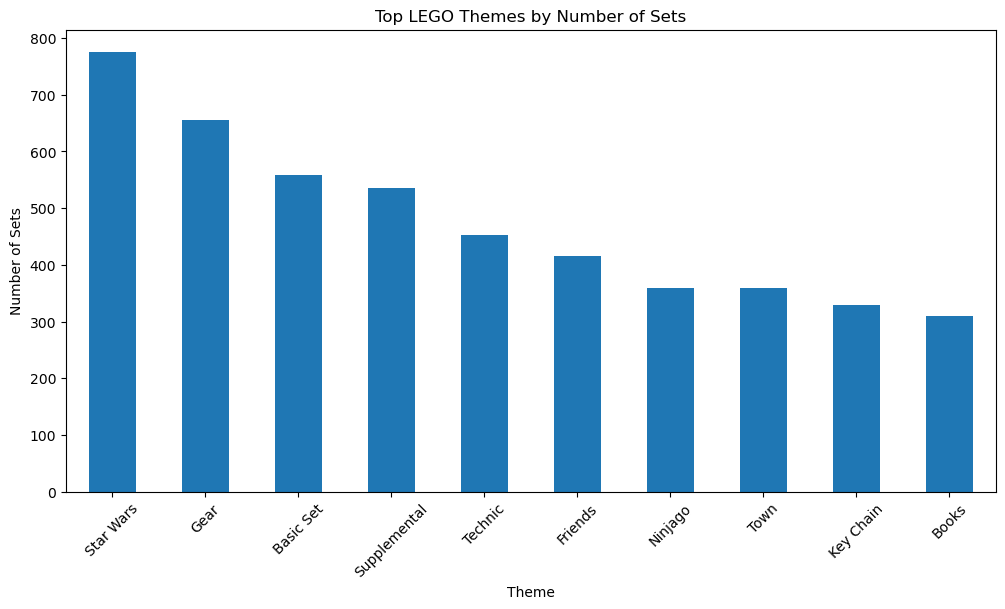

In [27]:
plt.figure(figsize=(12, 6))

sets_by_theme.head(10).plot(
    kind="bar"
)

plt.xlabel("Theme")
plt.ylabel("Number of Sets")
plt.title("Top LEGO Themes by Number of Sets")

plt.xticks(rotation=45)

plt.show()